In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install -q scikit-image albumentations

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import io
import albumentations as A


In [5]:
# DEFINE EVERYTHING IN ONE CELL (CRITICAL)
BASE_DATASET_PATH = "/content/drive/MyDrive/Oil_Spill_Project/Dataset/Module_1_Data_Collection- Piyush Ranjan/Dataset"

PART1_IMG_DIR  = BASE_DATASET_PATH + "/Sentinel_SAR_Part 1/01_Train_Val_Oil_Spill_images"
PART1_MASK_DIR = BASE_DATASET_PATH + "/Sentinel_SAR_Part 1/01_Train_Val_Oil_Spill_mask"

print("Image folder exists:", os.path.exists(PART1_IMG_DIR))
print("Mask folder exists :", os.path.exists(PART1_MASK_DIR))


Image folder exists: True
Mask folder exists : True


In [6]:
# LOAD FIRST SAR IMAGE SAFELY
img_spill = None

for root, _, files in os.walk(PART1_IMG_DIR):
    for f in files:
        if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg')):
            img_spill = io.imread(os.path.join(root, f))
            break
    if img_spill is not None:
        break

print("SAR Image Loaded:", img_spill is not None)
print("Image dtype:", img_spill.dtype if img_spill is not None else None)


SAR Image Loaded: True
Image dtype: float32


In [7]:
mask_spill = None

for root, _, files in os.walk(PART1_MASK_DIR):
    for f in files:
        if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg')):
            mask_spill = cv2.imread(os.path.join(root, f), cv2.IMREAD_GRAYSCALE)
            break
    if mask_spill is not None:
        break

print("Mask Loaded:", mask_spill is not None)


Mask Loaded: True


In [8]:
# Ensure SAR is single-channel
if img_spill.ndim == 3:
    img_spill = img_spill[:, :, 0]

print("Final SAR shape:", img_spill.shape)
print("Mask shape     :", mask_spill.shape)


Final SAR shape: (2048, 2048)
Mask shape     : (2048, 2048)


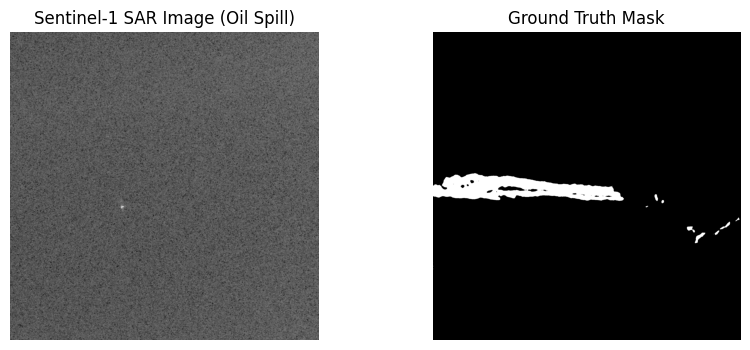

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Sentinel-1 SAR Image (Oil Spill)")
plt.imshow(img_spill, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Ground Truth Mask")
plt.imshow(mask_spill, cmap='gray')
plt.axis("off")

plt.show()


Min Pixel Value: -48.308517
Max Pixel Value: -1.5000436


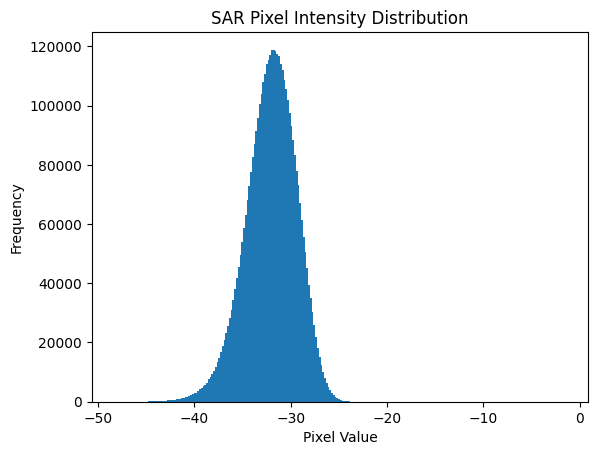

In [10]:
print("Min Pixel Value:", img_spill.min())
print("Max Pixel Value:", img_spill.max())

plt.hist(img_spill.flatten(), bins=256)
plt.title("SAR Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


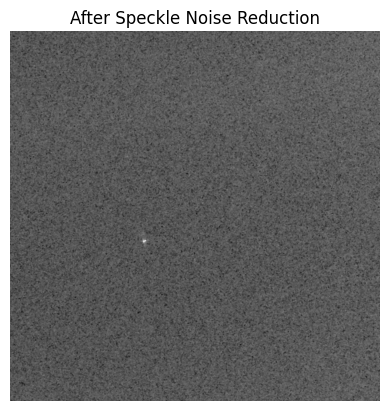

In [11]:
img_denoised = cv2.medianBlur(img_spill.astype(np.uint8), 5)

plt.imshow(img_denoised, cmap='gray')
plt.title("After Speckle Noise Reduction")
plt.axis("off")
plt.show()


In [12]:
IMG_SIZE = 256

img_resized  = cv2.resize(img_denoised, (IMG_SIZE, IMG_SIZE))
mask_resized = cv2.resize(mask_spill, (IMG_SIZE, IMG_SIZE))

img_norm  = img_resized.astype(np.float32) / 255.0
mask_norm = mask_resized.astype(np.float32) / 255.0

print("Final Image Shape:", img_norm.shape)
print("Pixel Range:", img_norm.min(), "to", img_norm.max())


Final Image Shape: (256, 256)
Pixel Range: 0.83137256 to 0.9882353


In [13]:
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.4)
])


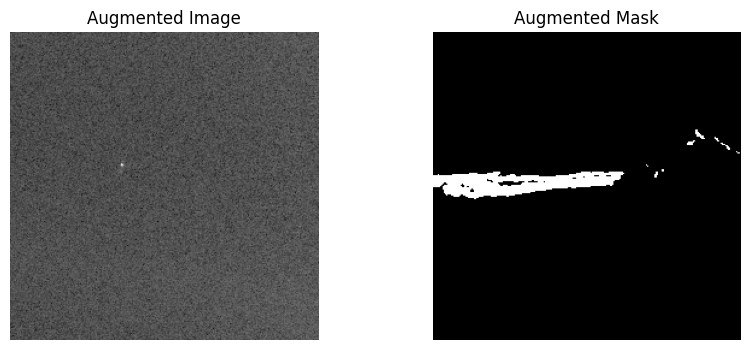

In [14]:
aug = augmenter(image=img_norm, mask=mask_norm)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Augmented Image")
plt.imshow(aug["image"], cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Augmented Mask")
plt.imshow(aug["mask"], cmap='gray')
plt.axis("off")

plt.show()


In [15]:
print("✅ MODULE 2 COMPLETED SUCCESSFULLY")
print("✔ SAR images visualized")
print("✔ Statistical properties studied")
print("✔ Speckle noise reduced")
print("✔ Images resized & normalized")
print("✔ Data augmentation applied")
print("✔ Dataset READY for Module 3, 4, 5")


✅ MODULE 2 COMPLETED SUCCESSFULLY
✔ SAR images visualized
✔ Statistical properties studied
✔ Speckle noise reduced
✔ Images resized & normalized
✔ Data augmentation applied
✔ Dataset READY for Module 3, 4, 5
